Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

- Zapoznaj się z analizą zbioru [twarzy OLivetti](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)
- Zapoznaj się z ze zbiorem [klasyfikacji cyfr](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

1. [0-1 pkt] Załaduj zbiór cyfr, a następnie wyświetl pierwsze 6 (2 wiersze, 3 kolumny) elementów zbioru za pomocą funkcji `plot_gallery()` (zob. pierwszy link)
1. [0-0.5 pkt] Podziel zbiór na treningowy i walidacyjny (czy zbiór jest zbalansowany i wystarczy zwykły podział losowy?). Pamiętaj, że skalowanie cech jak i dostrojenie redukcji wymiarowości (metoda `fit`) przeprowadzamy na zbiorze treningowym!
1. [0-2.5 pkt] Dokonaj transformacji zbioru `digits` przy użyciu (w każdym przypadku wyrysuj kilka przykładowych elementów zbioru):
   1. PCA
   2. [NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) (jaki będzie input?)
   3. [Factor Analysis](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html)
   4. [Jądrowy PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html) (przy użyciu przynajmniej trzech nieliniowych jąder)
2. [0-1.5 pkt] Wytrenuj regresję logistyczną na zbiorze oryginalnym (model *baseline*) oraz przetransformowanym za pomocą technik z punktu 3.
1. [0-1.5 pkt] Sporządź analizę porównawczą wyników zarówno dla zbioru treningowego jak i walidacyjnego. Wyrysuj macierz pomyłek oraz metryki zbiorcze
3. [0-1 pkt] Wybierz $n=32, 16, 8, 4, 2$ dominujące cechy w każdej metodzie i wykonaj analizę w pkt. 5.
1. [0-1 pkt] Skomentuj uzyskane wyniki. Czy redukcja wymiarowości jest optymalnym rozwiązaniem w przypadku tego zbioru? Jeśli tak, to która? Jeśli żadna, to dlaczego?
2. [0-1 pkt] Zaproponuj usprawnienie metodologii wyżej (np. inną technikę selekcji cech)

## Importy i konfiguracja

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF, FactorAnalysis, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42

## Zadanie 1


In [ ]:
digits = load_digits()
X, y = digits.data, digits.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Liczba klas: {len(np.unique(y))}")
print(f"Klasy: {np.unique(y)}")

X shape: (1797, 64)
y shape: (1797,)
Liczba klas: 10
Klasy: [0 1 2 3 4 5 6 7 8 9]


In [122]:
def plot_gallery(images, titles, h, w, n_row=2, n_col=3):
    fig, axes = plt.subplots(n_row, n_col, figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i].reshape(h, w), cmap=plt.cm.gray_r, interpolation="nearest")
            ax.set_title(titles[i], size=12)
        ax.set_xticks(())
        ax.set_yticks(())
    plt.show()

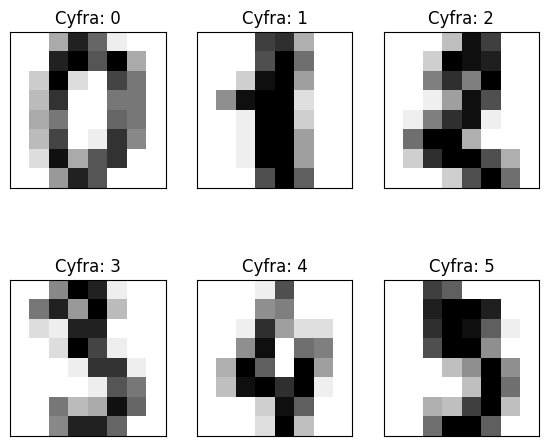

In [123]:
image_shape = digits.images[0].shape
h, w = image_shape

titles = [f"Cyfra: {y[i]}" for i in range(6)]
plot_gallery(X[:6], titles, h, w, n_row=2, n_col=3)

## Zadanie 2


Rozkład klas w zbiorze:
Klasa 0: 178 obiektów
Klasa 1: 182 obiektów
Klasa 2: 177 obiektów
Klasa 3: 183 obiektów
Klasa 4: 181 obiektów
Klasa 5: 182 obiektów
Klasa 6: 181 obiektów
Klasa 7: 179 obiektów
Klasa 8: 174 obiektów
Klasa 9: 180 obiektów


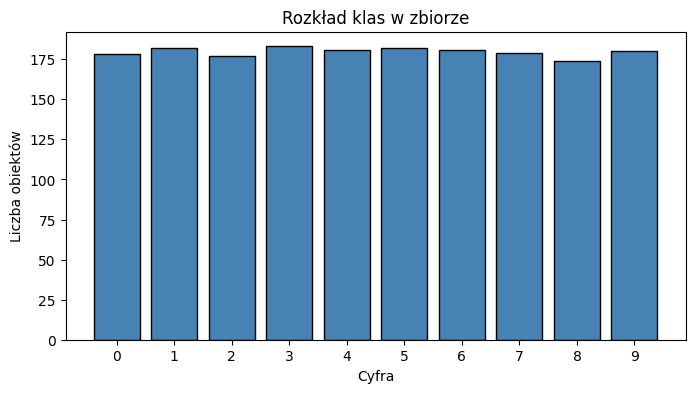


Min: 174, Max: 183, Różnica: 9


In [153]:
unique, counts = np.unique(y, return_counts=True)
print("Rozkład klas w zbiorze:")
for cls, cnt in zip(unique, counts):
    print(f"Klasa {cls}: {cnt} obiektów")

plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel('Cyfra')
plt.ylabel('Liczba obiektów')
plt.title('Rozkład klas w zbiorze')
plt.xticks(unique)
plt.show()

print(f"\nMin: {counts.min()}, Max: {counts.max()}, Różnica: {counts.max() - counts.min()}")

In [125]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [126]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_val_minmax = minmax_scaler.transform(X_val)

Z uzyskanch wyników widać, że zbiór jest **w przybliżeniu zbalansowany** - różnica między najmniej liczną, a najbardziej liczną klasą wynosi **9**. Dzięki temu nie musimy manipulować danymi w celu uzyskania lepszych wyników modeli, tak jakbyśmy zrobili w przypadku **mocno niezbalansowanego datasetu**. Daje nam to również zapewnienie, że **wystarczy nam zwykły podział losowy** bez wykorzystywania `stratify=y`. Przeprowadziłem też dwa rodzaje skalowania - `MinMaxScaler` dla NMF i `StandardScaler` dla reszty

## Zadanie 3


### PCA

In [127]:
n_components = 32

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"PCA: {X_train_scaled.shape[1]} do {X_train_pca.shape[1]} cech")

PCA: 64 do 32 cech


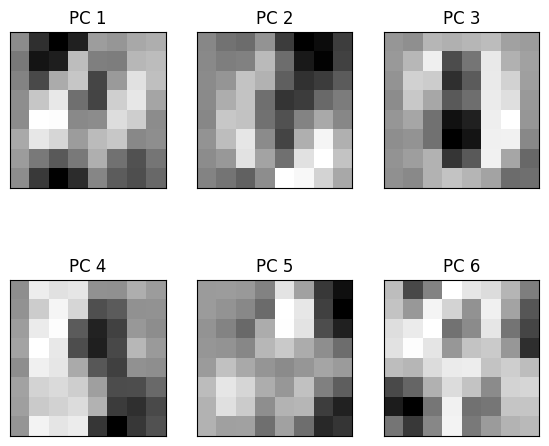

In [128]:
pca_titles = [f"PC {i+1}" for i in range(6)]
plot_gallery(pca.components_[:6], pca_titles, h, w, n_row=2, n_col=3)

### NMF

In [129]:
nmf = NMF(n_components=n_components, init='nndsvda', random_state=RANDOM_STATE, max_iter=500)
X_train_nmf = nmf.fit_transform(X_train_minmax)
X_val_nmf = nmf.transform(X_val_minmax)

print(f"NMF: {X_train_minmax.shape[1]} do {X_train_nmf.shape[1]} cech")

NMF: 64 do 32 cech


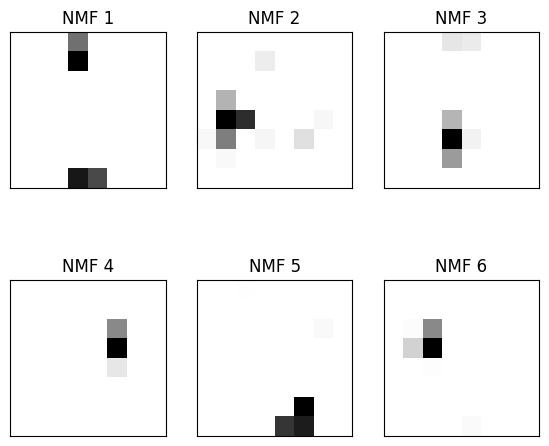

In [130]:
nmf_titles = [f"NMF {i+1}" for i in range(6)]
plot_gallery(nmf.components_[:6], nmf_titles, h, w, n_row=2, n_col=3)

### Factor Analysis

In [131]:
fa = FactorAnalysis(n_components=n_components, random_state=RANDOM_STATE)
X_train_fa = fa.fit_transform(X_train_scaled)
X_val_fa = fa.transform(X_val_scaled)

print(f"Factor Analysis: {X_train_scaled.shape[1]} do {X_train_fa.shape[1]} cech")

Factor Analysis: 64 do 32 cech


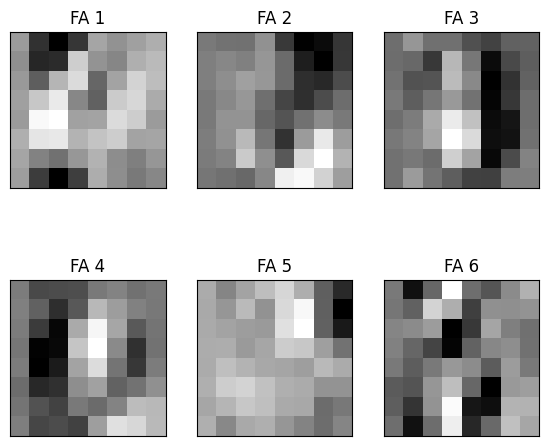

In [132]:
fa_titles = [f"FA {i+1}" for i in range(6)]
plot_gallery(fa.components_[:6], fa_titles, h, w, n_row=2, n_col=3)

### Jądrowy PCA
Wykorzystamy trzy nieliniowe jądra: **rbf**, **poly**, **sigmoid**

In [133]:
kernels = ['rbf', 'poly', 'sigmoid']
kpca_models = {}
X_train_kpca = {}
X_val_kpca = {}

for kernel in kernels:
    kpca = KernelPCA(n_components=n_components, kernel=kernel, random_state=RANDOM_STATE, fit_inverse_transform=True, alpha=1.0)
    X_train_kpca[kernel] = kpca.fit_transform(X_train_scaled)
    X_val_kpca[kernel] = kpca.transform(X_val_scaled)
    kpca_models[kernel] = kpca
    print(f"Kernel PCA ({kernel}): {X_train_scaled.shape[1]} do {X_train_kpca[kernel].shape[1]} cech")

Kernel PCA (rbf): 64 do 32 cech
Kernel PCA (poly): 64 do 32 cech
Kernel PCA (sigmoid): 64 do 32 cech


Dla KPCA nie ma wizualizacji, ponieważ z racji, iż jest to nieliniowe przekształcenie nie posiada metody `components_` i nie da się łatwo tego narysować

Metoda NMF zawsze wyciąga małe zarysowane fragmenty (np. pojedyncze kreski czy łuki) i na podstawie sumy tych fragmentów zgaduje całą cyfrę. Z kolei w PCA i FA widzimy reprezentację globalną, czyli rozmyte zarysy całych cyfr naraz, ponieważ tam piksele mogą przyjmować wartości ujemne i po prostu się redukować


## Zadanie 4

In [135]:
def train_and_evaluate(X_tr, X_v, y_tr, y_v, name):
    lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_tr, y_tr)
    
    y_train_pred = lr.predict(X_tr)
    y_val_pred = lr.predict(X_v)
    
    results = {
        'name': name,
        'train_acc': accuracy_score(y_tr, y_train_pred),
        'val_acc': accuracy_score(y_v, y_val_pred),
        'train_f1': f1_score(y_tr, y_train_pred, average='weighted'),
        'val_f1': f1_score(y_v, y_val_pred, average='weighted'),
        'y_train_pred': y_train_pred,
        'y_val_pred': y_val_pred,
        'model': lr
    }
    return results

In [136]:
results_baseline = train_and_evaluate(X_train_scaled, X_val_scaled, y_train, y_val, 'Baseline (oryginalne)')
results_pca = train_and_evaluate(X_train_pca, X_val_pca, y_train, y_val, 'PCA')
results_nmf = train_and_evaluate(X_train_nmf, X_val_nmf, y_train, y_val, 'NMF')
results_fa = train_and_evaluate(X_train_fa, X_val_fa, y_train, y_val, 'Factor Analysis')

results_kpca = {}
for kernel in kernels:
    results_kpca[kernel] = train_and_evaluate(
        X_train_kpca[kernel], X_val_kpca[kernel], y_train, y_val, f'KernelPCA ({kernel})'
    )

all_results = [results_baseline, results_pca, results_nmf, results_fa] + \
              [results_kpca[k] for k in kernels]

## Zadanie 5

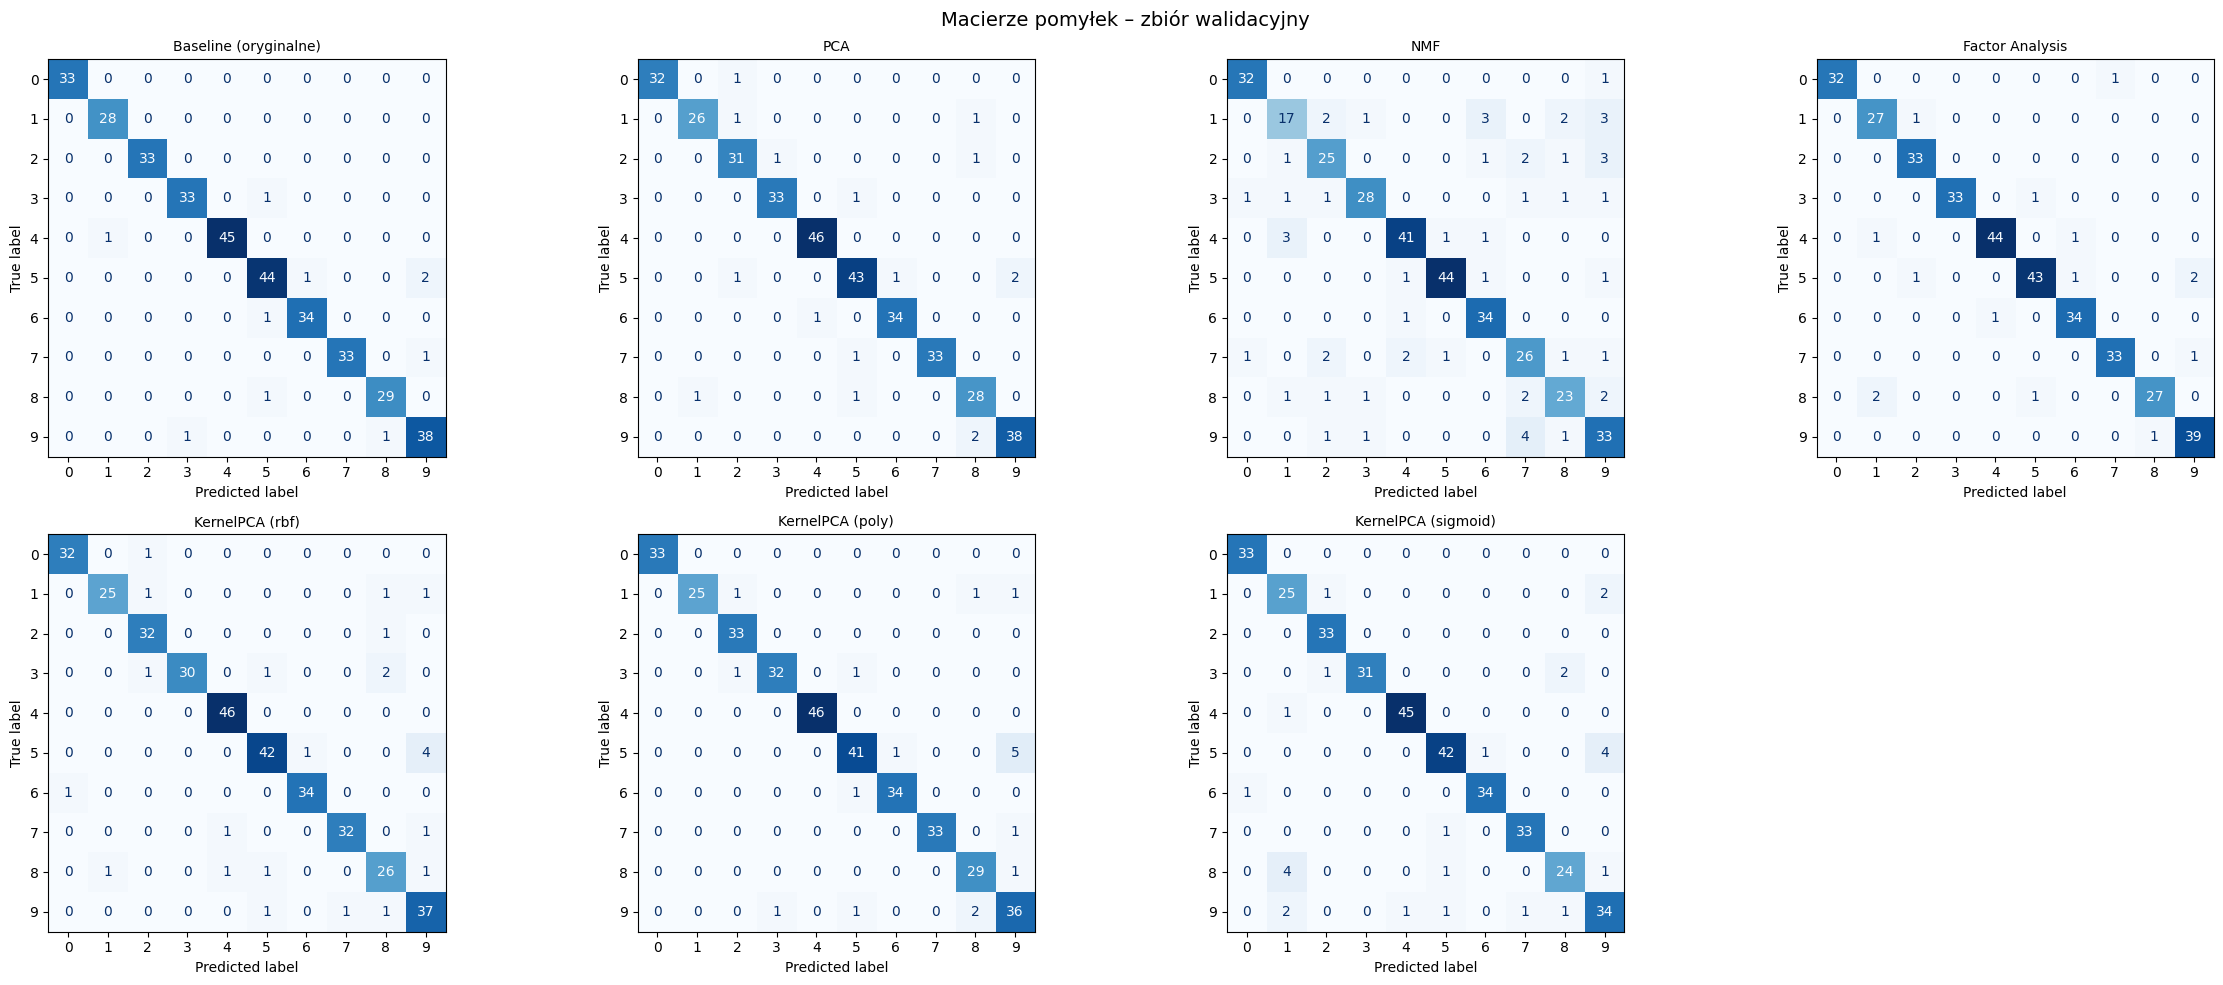

In [137]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, r in enumerate(all_results):
    if i < len(axes):
        cm = confusion_matrix(y_val, r['y_val_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(r['name'], fontsize=10)

for j in range(len(all_results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Macierze pomyłek – zbiór walidacyjny', fontsize=14)
plt.tight_layout()
plt.show()

In [154]:
metrics_data = []
for r in all_results:
    prec_train = precision_score(y_train, r['y_train_pred'], average='weighted')
    rec_train = recall_score(y_train, r['y_train_pred'], average='weighted')
    prec_val = precision_score(y_val, r['y_val_pred'], average='weighted')
    rec_val = recall_score(y_val, r['y_val_pred'], average='weighted')
    
    metrics_data.append({
        'Metoda': r['name'],
        'Train Accuracy': r['train_acc'],
        'Val Accuracy': r['val_acc'],
        'Train Precision': prec_train,
        'Val Precision': prec_val,
        'Train Recall': rec_train,
        'Val Recall': rec_val,
        'Train F1': r['train_f1'],
        'Val F1': r['val_f1']
    })

df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Metoda', inplace=True)
display(df_metrics.round(4))

,Train Accuracy,Val Accuracy,Train Precision,Val Precision,Train Recall,Val Recall,Train F1,Val F1
Metoda,,,,,,,,
Baseline (oryginalne),0.9986,0.9722,0.9986,0.9725,0.9986,0.9722,0.9986,0.9723
PCA,0.9923,0.9556,0.9924,0.9563,0.9923,0.9556,0.9923,0.9557
NMF,0.8253,0.8417,0.8291,0.8424,0.8253,0.8417,0.8242,0.8405
Factor Analysis,0.9889,0.9583,0.9890,0.9593,0.9889,0.9583,0.9889,0.9583
KernelPCA (rbf),0.9499,0.9333,0.9513,0.9356,0.9499,0.9333,0.9501,0.9336
KernelPCA (poly),0.9582,0.9500,0.9589,0.9522,0.9582,0.9500,0.9583,0.9503
KernelPCA (sigmoid),0.9443,0.9278,0.9451,0.9298,0.9443,0.9278,0.9444,0.9279


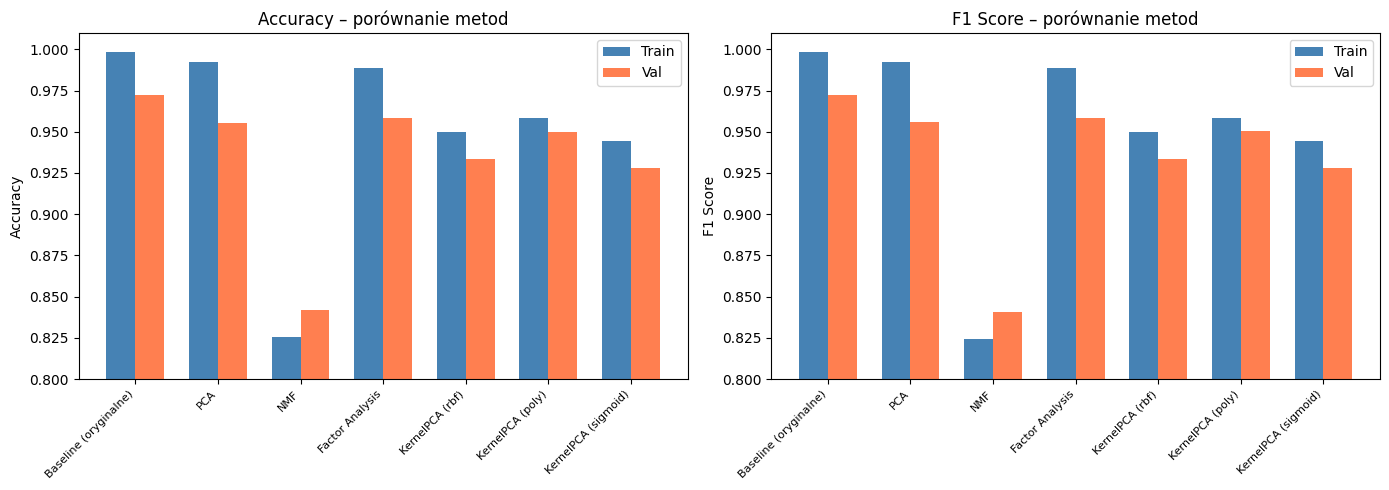

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = [r['name'] for r in all_results]
train_accs = [r['train_acc'] for r in all_results]
val_accs = [r['val_acc'] for r in all_results]

x = np.arange(len(methods))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, val_accs, width, label='Val', color='coral')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy – porównanie metod')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].set_ylim(0.8, 1.01)

train_f1s = [r['train_f1'] for r in all_results]
val_f1s = [r['val_f1'] for r in all_results]

axes[1].bar(x - width/2, train_f1s, width, label='Train', color='steelblue')
axes[1].bar(x + width/2, val_f1s, width, label='Val', color='coral')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score – porównanie metod')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
axes[1].legend()
axes[1].set_ylim(0.8, 1.01)

plt.tight_layout()
plt.show()

Baseline osiąga najwyższe wyniki we wszystkich metrykach (Accuracy, Precision, Recall, F1 – zarówno na zbiorze treningowym, jak i walidacyjnym). **Factor Analysis jest najlepszą metodą redukcji wymiarowości** dla tego zbioru (Val Acc = 0.9583, Val F1 = 0.9583), tuż za nią plasuje się PCA. Kernel PCA z jądrami rbf, poly i sigmoid osiąga dobre, ale niższe wyniki (0.92–0.94). **NMF jest zdecydowanie najsłabszą metodą** z wynikami ~0.84, co sugeruje, że nieujemna faktoryzacja nie jest odpowiednia dla tego typu danych przy 32 komponentach

## Zadanie 6

In [140]:
n_components_list = [32, 16, 8, 4, 2]

results_by_n = {}

for n in n_components_list:
    results_by_n[n] = {}
    
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    Xtr_pca = pca_n.fit_transform(X_train_scaled)
    Xv_pca = pca_n.transform(X_val_scaled)
    results_by_n[n]['PCA'] = train_and_evaluate(Xtr_pca, Xv_pca, y_train, y_val, f'PCA (n={n})')
    
    nmf_n = NMF(n_components=n, init='nndsvda', random_state=RANDOM_STATE, max_iter=500)
    Xtr_nmf = nmf_n.fit_transform(X_train_minmax)
    Xv_nmf = nmf_n.transform(X_val_minmax)
    results_by_n[n]['NMF'] = train_and_evaluate(Xtr_nmf, Xv_nmf, y_train, y_val, f'NMF (n={n})')
    
    fa_n = FactorAnalysis(n_components=n, random_state=RANDOM_STATE)
    Xtr_fa = fa_n.fit_transform(X_train_scaled)
    Xv_fa = fa_n.transform(X_val_scaled)
    results_by_n[n]['FA'] = train_and_evaluate(Xtr_fa, Xv_fa, y_train, y_val, f'FA (n={n})')
    
    for kernel in kernels:
        kpca_n = KernelPCA(n_components=n, kernel=kernel, random_state=RANDOM_STATE)
        Xtr_kpca = kpca_n.fit_transform(X_train_scaled)
        Xv_kpca = kpca_n.transform(X_val_scaled)
        results_by_n[n][f'KPCA-{kernel}'] = train_and_evaluate(
            Xtr_kpca, Xv_kpca, y_train, y_val, f'KPCA-{kernel} (n={n})'
        )

In [141]:
rows = []
for n in n_components_list:
    for method_name, r in results_by_n[n].items():
        rows.append({
            'n_components': n,
            'Metoda': method_name,
            'Train Acc': r['train_acc'],
            'Val Acc': r['val_acc'],
            'Train F1': r['train_f1'],
            'Val F1': r['val_f1']
        })

df_n_results = pd.DataFrame(rows)

for n in n_components_list:
    print(f"n_components = {n}")
    subset = df_n_results[df_n_results['n_components'] == n].drop(columns='n_components')
    display(subset.round(4))


n_components = 32


,Metoda,Train Acc,Val Acc,Train F1,Val F1
0,PCA,0.9923,0.9556,0.9923,0.9557
1,NMF,0.8253,0.8417,0.8242,0.8405
2,FA,0.9889,0.9583,0.9889,0.9583
3,KPCA-rbf,0.9499,0.9333,0.9501,0.9336
4,KPCA-poly,0.9582,0.9500,0.9583,0.9503
5,KPCA-sigmoid,0.9443,0.9278,0.9444,0.9279


n_components = 16


,Metoda,Train Acc,Val Acc,Train F1,Val F1
6,PCA,0.9652,0.9306,0.9653,0.9311
7,NMF,0.7954,0.8083,0.7945,0.8070
8,FA,0.9603,0.9417,0.9603,0.9419
9,KPCA-rbf,0.9290,0.9250,0.9293,0.9251
10,KPCA-poly,0.8128,0.7972,0.8122,0.7953
11,KPCA-sigmoid,0.9360,0.9222,0.9361,0.9218


n_components = 8


,Metoda,Train Acc,Val Acc,Train F1,Val F1
12,PCA,0.8782,0.8806,0.8785,0.8781
13,NMF,0.7314,0.7167,0.7107,0.7041
14,FA,0.8761,0.8944,0.8761,0.8940
15,KPCA-rbf,0.8525,0.8306,0.8516,0.8295
16,KPCA-poly,0.4558,0.4500,0.3941,0.3942
17,KPCA-sigmoid,0.8392,0.8444,0.8325,0.8365


n_components = 4


,Metoda,Train Acc,Val Acc,Train F1,Val F1
18,PCA,0.7996,0.7861,0.7982,0.7826
19,NMF,0.6347,0.6500,0.5942,0.6099
20,FA,0.7794,0.7611,0.7774,0.7605
21,KPCA-rbf,0.7168,0.7306,0.7105,0.7171
22,KPCA-poly,0.2081,0.1694,0.1338,0.1100
23,KPCA-sigmoid,0.7578,0.7639,0.7460,0.7518


n_components = 2


,Metoda,Train Acc,Val Acc,Train F1,Val F1
24,PCA,0.5505,0.5167,0.5226,0.4836
25,NMF,0.3243,0.3000,0.2368,0.2095
26,FA,0.4843,0.4722,0.4468,0.4449
27,KPCA-rbf,0.5762,0.5778,0.5610,0.5516
28,KPCA-poly,0.1232,0.0889,0.0483,0.0318
29,KPCA-sigmoid,0.5115,0.5222,0.4636,0.4746


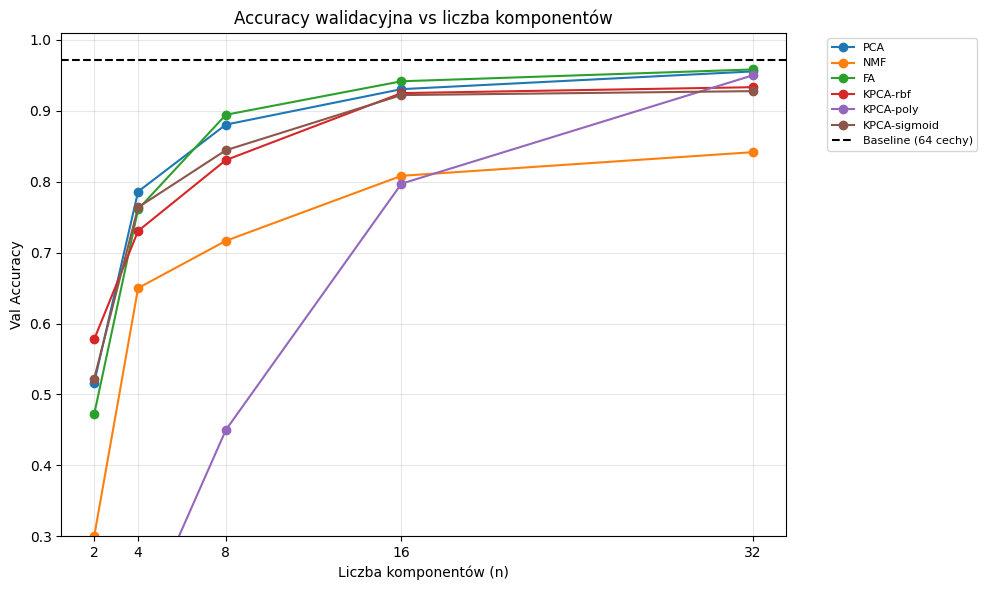

In [ ]:
method_names_unique = list(results_by_n[32].keys())

fig, ax = plt.subplots(figsize=(10, 6))

for method in method_names_unique:
    val_accs_per_n = [results_by_n[n][method]['val_acc'] for n in n_components_list]
    ax.plot(n_components_list, val_accs_per_n, 'o-', label=method)

ax.axhline(y=results_baseline['val_acc'], color='black', linestyle='--', label='Baseline (64 cechy)')

ax.set_xlabel('Liczba komponentów (n)')
ax.set_ylabel('Val Accuracy')
ax.set_title('Accuracy walidacyjna vs liczba komponentów')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_xticks(n_components_list)
ax.set_ylim(0.3, 1.01)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

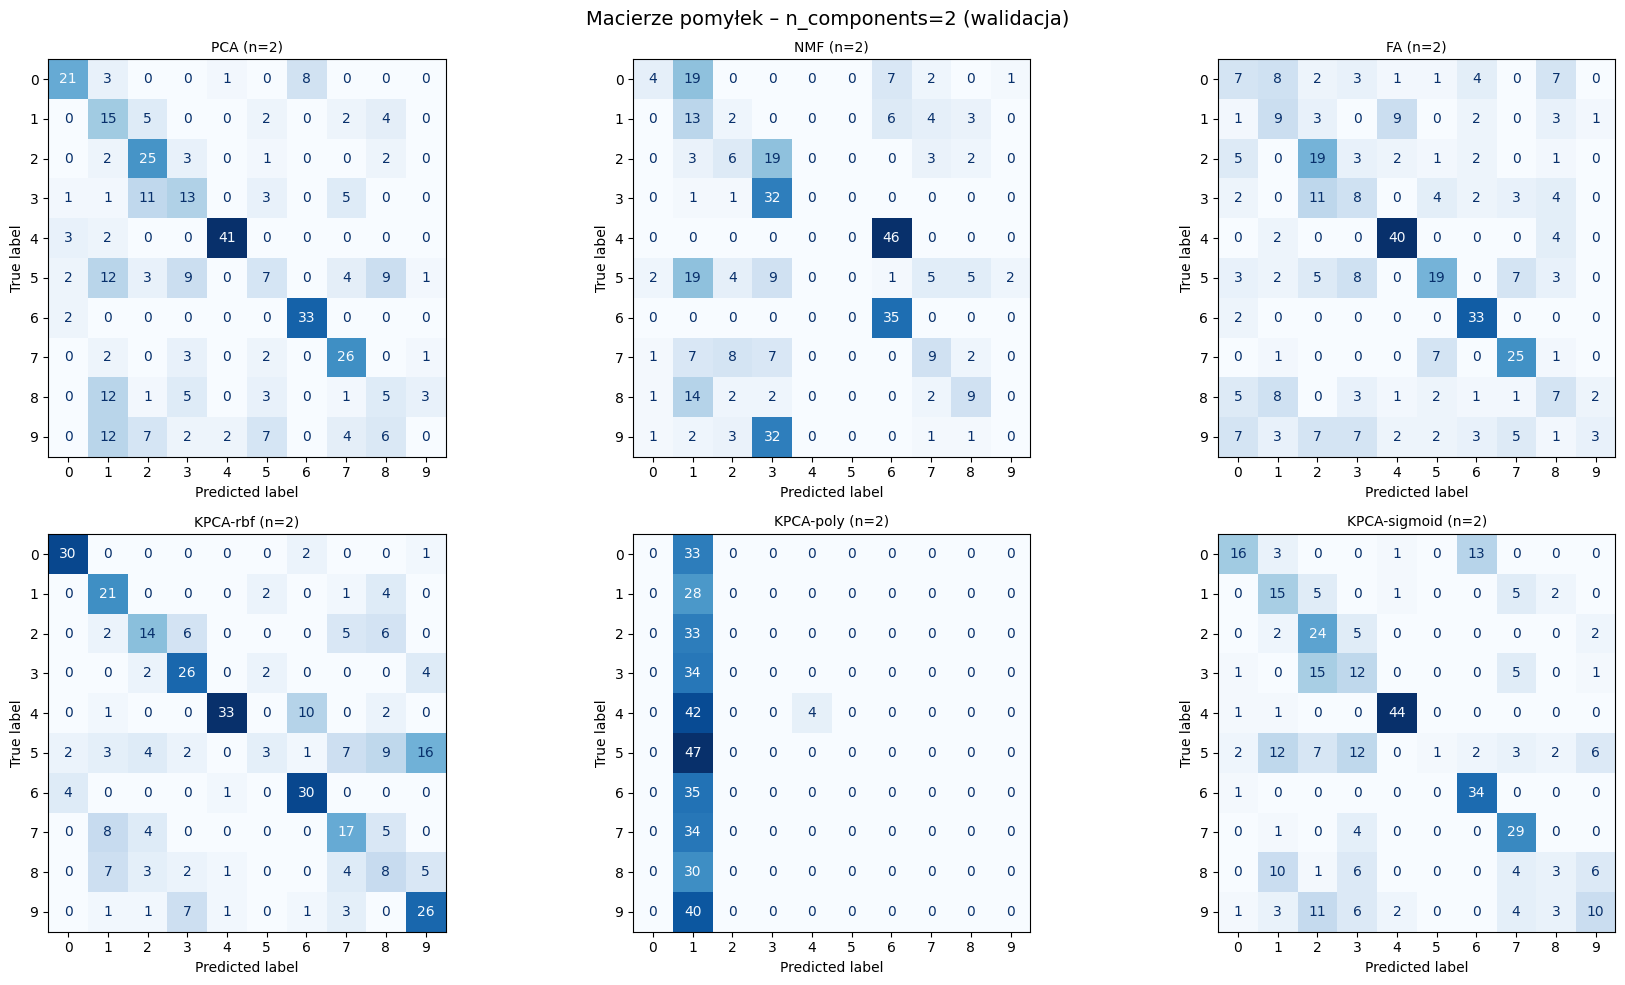

In [143]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (method, r) in enumerate(results_by_n[2].items()):
    if i < len(axes):
        cm = confusion_matrix(y_val, r['y_val_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(f"{method} (n=2)", fontsize=10)

plt.suptitle('Macierze pomyłek – n_components=2 (walidacja)', fontsize=14)
plt.tight_layout()
plt.show()

## Zadanie 7

Analizując dokładność na zbiorze walidacyjnym modeli regresji logistycznej trenowanych na zredukowanych zestawach cech, możemy powiedzieć, że:

**1. Czy redukcja wymiarowości jest optymalnym rozwiązaniem?**
Tak, ale tylko do pewnego momentu. Oryginalny zbiór osiągnął dokładność na poziomie ok. **97.2%**. Zmniejszenie liczby cech o połowę (do **n=32**) przy użyciu najlepszych metod (Factor Analysis, PCA) daje wynik rzędu **95.6% - 95.8%**. Utrata niecałych 2 punktów procentowych przy redukcji rozmiaru danych o 50% to bardzo dobry wynik, warty kompromisu. Dla **n=16** (kompresja o 75%) dokładność wciąż utrzymuje się na wysokim poziomie **93.1% - 94.2%**. Redukcja poniżej 8 wymiarów (n=4, n=2) powoduje już drastyczny spadek trafności (poniżej 80%), co pokazuje, że zbiór nie nadaje się do drastycznego zmniejszania liczby cech, gdyż tracimy wtedy za dużo informacji

**2. Która metoda jest najlepsza?**
Najlepszymi i najbardziej stabilnymi metodami redukcji dla tego zbioru okazały się **Factor Analysis (FA)** oraz klasyczne **PCA**.
- Dla **n=32** FA osiąga najwyższy wynik: **95.8%**, a PCA **95.6%**.
- Dla **n=16** FA utrzymuje prowadzenie z wynikiem **94.2%**, a PCA osiąga **93.1%**
- Dla **n=8** wyniki obu metod wynoszą odpowiednio **89.4%** i **88.1%**


## Zadanie 8

Zamiast transformować cechy (jak w PCA/NMF/FA), możemy **wybrać najważniejsze oryginalne cechy** za pomocą:
1. **Mutual Information** – mierzy zależność między cechą a zmienną docelową
2. **SelectKBest z chi2** – test statystyczny istotności cech

Zalety selekcji cech:
- Zachowujemy oryginalne cechy, co daje nam lepszą interpretowalność
- Unikamy artefaktów transformacji
- Możemy połączyć selekcję cech z redukcją wymiarowości (pipeline)

In [144]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2

mi_results = {}
for n in n_components_list:
    selector = SelectKBest(mutual_info_classif, k=n)
    Xtr_mi = selector.fit_transform(X_train_scaled, y_train)
    Xv_mi = selector.transform(X_val_scaled)
    mi_results[n] = train_and_evaluate(Xtr_mi, Xv_mi, y_train, y_val, f'MI (n={n})')

chi2_results = {}
for n in n_components_list:
    selector = SelectKBest(chi2, k=n)
    Xtr_chi2 = selector.fit_transform(X_train_minmax, y_train)
    Xv_chi2 = selector.transform(X_val_minmax)
    chi2_results[n] = train_and_evaluate(Xtr_chi2, Xv_chi2, y_train, y_val, f'Chi2 (n={n})')

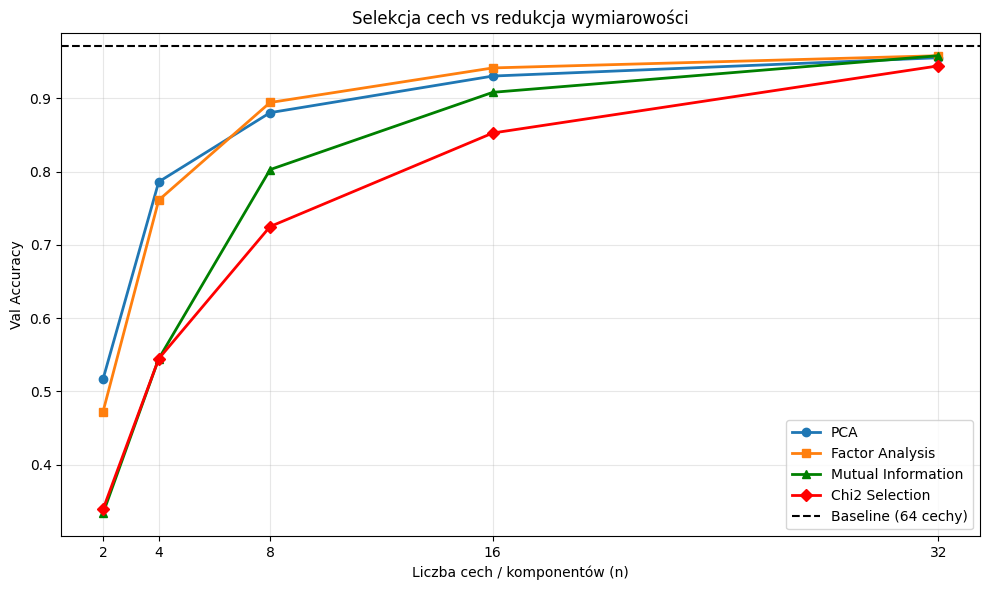

In [145]:
fig, ax = plt.subplots(figsize=(10, 6))

pca_vals = [results_by_n[n]['PCA']['val_acc'] for n in n_components_list]
ax.plot(n_components_list, pca_vals, 'o-', label='PCA', linewidth=2)

fa_vals = [results_by_n[n]['FA']['val_acc'] for n in n_components_list]
ax.plot(n_components_list, fa_vals, 's-', label='Factor Analysis', linewidth=2)

mi_vals = [mi_results[n]['val_acc'] for n in n_components_list]
ax.plot(n_components_list, mi_vals, '^-', label='Mutual Information', linewidth=2, color='green')

chi2_vals = [chi2_results[n]['val_acc'] for n in n_components_list]
ax.plot(n_components_list, chi2_vals, 'D-', label='Chi2 Selection', linewidth=2, color='red')

ax.axhline(y=results_baseline['val_acc'], color='black', linestyle='--', label='Baseline (64 cechy)')

ax.set_xlabel('Liczba cech / komponentów (n)')
ax.set_ylabel('Val Accuracy')
ax.set_title('Selekcja cech vs redukcja wymiarowości')
ax.legend()
ax.set_xticks(n_components_list)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
rows = []
for n in n_components_list:
    rows.append({
        'n': n,
        'PCA': results_by_n[n]['PCA']['val_acc'],
        'FA': results_by_n[n]['FA']['val_acc'],
        'MI': mi_results[n]['val_acc'],
        'Chi2': chi2_results[n]['val_acc']
    })

df_compare = pd.DataFrame(rows)
print("Porównanie – Selekcja cech vs PCA i FA")
display(df_compare.round(4))

Porównanie – Selekcja cech vs PCA i FA


,n,PCA,FA,MI,Chi2
0,32,0.9556,0.9583,0.9583,0.9444
1,16,0.9306,0.9417,0.9083,0.8528
2,8,0.8806,0.8944,0.8028,0.7250
3,4,0.7861,0.7611,0.5444,0.5444
4,2,0.5167,0.4722,0.3333,0.3389


Analizując powyższą tabele z wynikami z `Mutal Information` i `Chi2` widać, że: 

1. **Przy lekkiej redukcji (n=32)**: Odrzucenie połowy najmniej istotnych pikseli sprawdza się świetnie. Metoda Mutual Information osiąga tu 95.83%, dorównując najlepszej ekstrakcji (FA). Oznacza to, że znaczna część oryginalnych pikseli to po prostu zbędne, puste tło obrazka, które można odciąć bez utraty jakości
2. **Przy silnej kompresji (n <= 16)**: Ekstrakcja wygrywa z ogromną przewagą. Dla n=4, PCA utrzymuje 78.6% dokładności, kiedy to selekcja zaledwie 54.4%. Dzieje się tak, ponieważ PCA kondensuje globalne informacje strukturalne z całego obrazka do 4 wymiarów, podczas gdy selekcja zostawia model z zaledwie 4 pikselami, co zupełnie nie wystarcza by rozróżnić kształt cyfry
